<center><h1><u>宝可梦卡牌电商定价分析与价格预测</u></h1></center>


本次项目探索了从国际电商平台收集的真实已售宝可梦集换式卡牌游戏 (TCG) 商品信息。数据集涵盖了从经典基础系列到现代绯红与紫罗兰系列的所有卡牌，包括评级卡、稀有度信息、语言元数据、卖家行为以及标准化的美元价格。

分析的重点在于理解宝可梦卡牌价格背后的经济驱动因素，并识别哪些特征对收藏市场价值的贡献最大。

本笔记本涵盖以下内容：

- 探索性数据分析

- 市场细分

- 定价动态

- 评级卡与裸卡对比分析

- 卖家行为分析

- 统计分析

- 特征工程

- 商品标题的自然语言处理 (NLP)

- 机器学习回归

- 模型解释

- 集成学习

数据集规模相对较小，但其特征深度为结构化分析和预测建模奠定了坚实的基础。


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

from sklearn.compose import TransformedTargetRegressor

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from wordcloud import WordCloud

import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

PALETTE_MAIN = "mako"
PALETTE_ALT = "flare"
PALETTE_CAT = "viridis"

RANDOM_STATE = 42

In [6]:
# 加载数据

DATA_PATH = "C:\\Users\\zhu30\\Desktop\\简历\\archive\\pokemon_cards_ultimate_2026.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()


Dataset Shape: (542, 32)


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge ex SAR 203/187 SV8a Terastal Fest ex...,Ceruledge,SV8A,203/187,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian V Holo SAR 225/172 S12a VSTAR Universe ...,Zacian,S12A,225/172,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup AR 085/080 M2 Japanese Pokemon Card Jap...,Piplup,INFERNO X,085/080,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,POKEMON Card Kyurem EX 25/98 XY Ancient Origin...,Kyurem,XY,25/98,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Pokemon Card Vulpix AR 067/063 M1L Mega Brave ...,Vulpix,MEGA BRAVE,067/063,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


In [7]:
# 看眼数据

display(df.sample(5))

print("\nMissing Values:\n")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
379,Lt. Surge's Magneton Gym Heroes No.082 Holo Ex...,Unknown,Unknown,NaN,Unknown,Japanese,Single Cards,Excellent,0,NaN,...,EUR,7.62,Common,Germany,114,1,2,4.0,5.0,2026.0
461,Pokemon Pikachu TCG XY95 Black Star Promo Holo...,Pikachu,XY95,NaN,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,108.82,Rare,United Kingdom,1,0,2,4.0,5.0,2026.0
165,Mega Lucario ex - 113/217 - Ascended Heroes - ...,Lucario,Unknown,113/217,RR,English,Single Cards,Near Mint,0,NaN,...,GBP,1.35,Budget,United Kingdom,26,0,2,4.0,5.0,2026.0
130,Pokemon Card Japanese - M Venusaur Ex #002 - E...,Venusaur,Unknown,NaN,Unknown,Japanese,Single Cards,PSA 10,1,PSA,...,EUR,141.31,Rare,Italy,7,0,3,4.0,5.0,2026.0
313,Team Rockets Mewtwo ex - 063/193 - M2a Mega Dr...,Mewtwo,TEAM ROCKET,063/193,RR,English,Single Cards,Near Mint,0,NaN,...,EUR,1.17,Budget,Germany,114,1,2,3.0,5.0,2026.0



Missing Values:



numeric_grade           512
grading_company         503
card_number             131
sale_year                 4
days_since_sold           4
sale_month                4
rarity_class              0
title                     0
condition_std             0
category                  0
is_graded                 0
is_holo                   0
is_full_art               0
language                  0
pokemon_name              0
set_name                  0
is_gx_card                0
is_ex_card                0
is_v_card                 0
is_promo                  0
is_gold                   0
is_shadowless             0
is_1st_edition            0
is_rainbow                0
price_usd                 0
currency                  0
price                     0
price_tier_usd            0
ships_worldwide           0
seller_listing_count      0
seller_country            0
image_count               0
dtype: int64


Duplicate Rows: 1


# 数据清洗和特征工程

数据集结构良好，但以下几项改进有助于后续的分析和建模：

- 规范化缺失的评分值

- 创建对数价格特征

- 构建标题长度特征

- 将二元标志转换为适合分类的格式

- 提取其他文本特征

代码分析思路如下：

-grading_company（评级公司）：将空值填充为 "Ungraded"（未评级），表示这张卡没有被任何评级机构评分
-numeric_grade（数值评分）：将空值填充为 0，配合上面的逻辑，未评级的卡分数为 0

想了一下，这里因为未评级的卡在市场是有价格的但是价格区间很不好说，我们重点分析的还是UR,SSR之类的稀有卡牌的价值对于收藏市场的影响，所以将没有评级的卡全部填充为0。这里就不能使用插值法这类数学方法进行预测填充了，因为在市场经济中使用预测数据很可能造成误差的加大和噪音的增加。在逻辑上可以将空值填充为0，为了鲁棒性也不该使用数学方法进行填充。

-使用 log1p（即 log(1+x)）对价格进行对数变换

目的：
处理价格数据的长尾分布（少数天价卡，大量平价卡）
让数据更接近正态分布，便于后续建模
log1p 比 log 更安全，避免价格为 0 时出现负无穷。

设置布尔值
目的：机器学习模型需要数值输入，相当于一个二分类。

In [8]:
df["grading_company"] = df["grading_company"].fillna("Ungraded")
df["numeric_grade"] = df["numeric_grade"].fillna(0)

df["log_price_usd"] = np.log1p(df["price_usd"])

df["title_length"] = df["title"].astype(str).apply(len)
df["word_count"] = df["title"].astype(str).apply(lambda x: len(x.split()))

binary_cols = [
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "ships_worldwide"
]

for col in binary_cols:
    df[col] = df[col].astype(int)

df.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,542,536,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pokemon_name,542,76,Unknown,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
set_name,542,80,Unknown,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_number,411,387,085/080,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rarity_class,542,13,Unknown,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,542,6,English,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,542,2,Single Cards,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition_std,542,10,Near Mint,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_graded,542.0,NaN,NaN,NaN,0.071956,0.258653,0.0,0.0,0.0,0.0,1.0
grading_company,542,5,Ungraded,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 探索性数据分析

这里没什么好说的，左边是原始价格的分布，右边是使用上面提到的对数进行对数变换后的价格分布，从这里就能看出减小拖尾的好处。

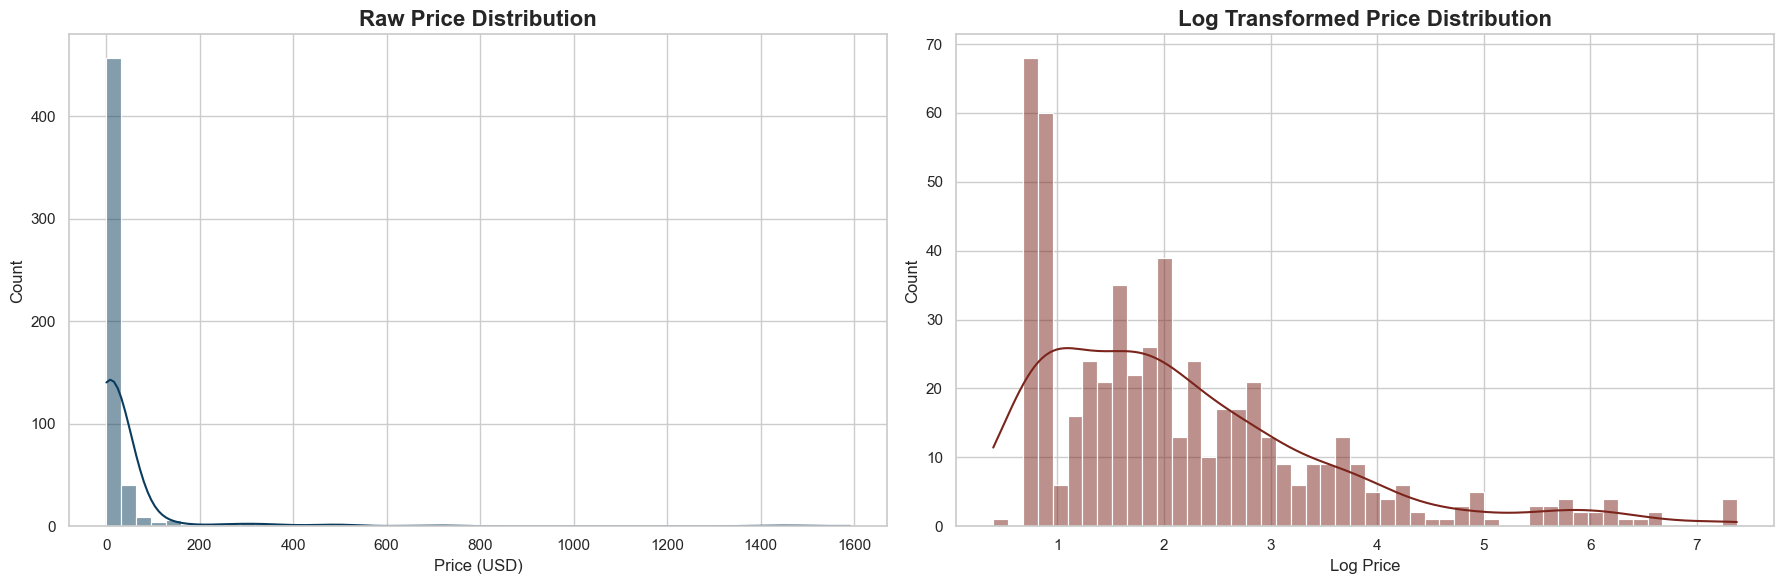

In [9]:
# 价格分布可视化

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df["price_usd"], bins=50, kde=True, ax=axes[0], color="#0B3C5D")
axes[0].set_title("Raw Price Distribution", fontsize=16, weight="bold")
axes[0].set_xlabel("Price (USD)")

sns.histplot(df["log_price_usd"], bins=50, kde=True, ax=axes[1], color="#7B241C")
axes[1].set_title("Log Transformed Price Distribution", fontsize=16, weight="bold")
axes[1].set_xlabel("Log Price")

plt.tight_layout()
plt.show()




原始价格分布呈现极度右偏态，这在收藏品市场中很常见，因为少数高价商品往往主导着整体价值。经过对数变换后，分布变得更加正态化，更适合进行回归建模。

这也证实了高价值的评级老卡相对于大多数中低档商品而言，属于统计上的异常值。


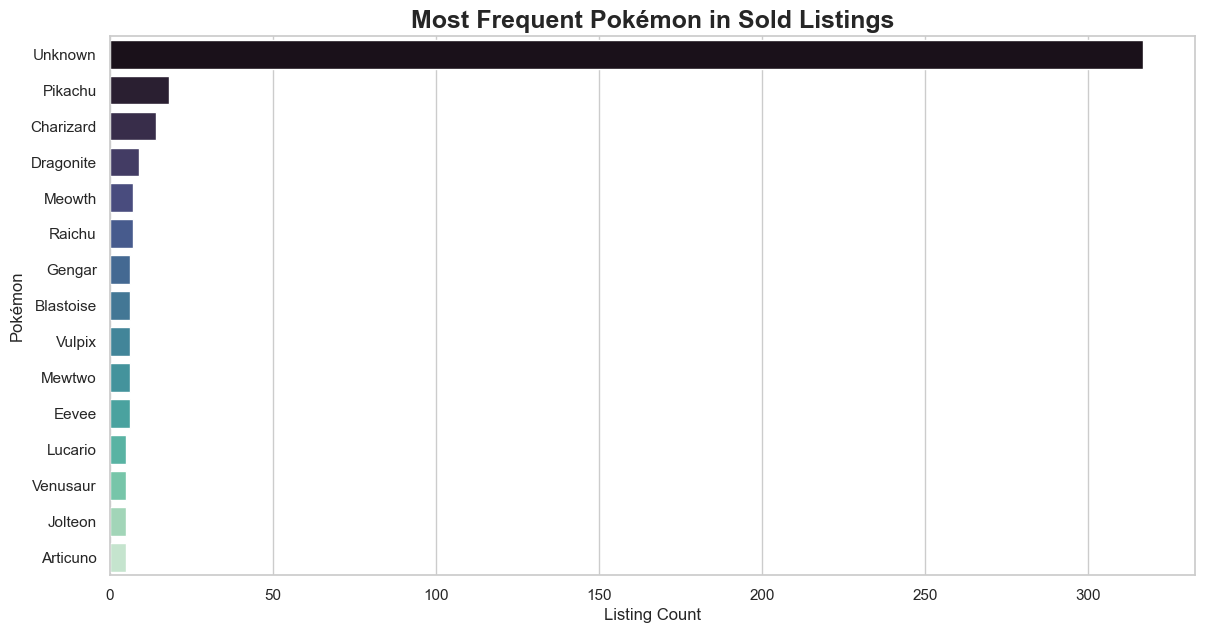

In [10]:
# 按上架次数排名的热门宝可梦

top_pokemon = df["pokemon_name"].value_counts().head(15)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=top_pokemon.values,
    y=top_pokemon.index,
    palette=sns.color_palette(PALETTE_MAIN, len(top_pokemon))
)

plt.title("Most Frequent Pokémon in Sold Listings", fontsize=18, weight="bold")
plt.xlabel("Listing Count")
plt.ylabel("Pokémon")

plt.show()



相对较少的宝可梦卡牌占据了交易市场的大部分份额。热门系列标志性角色经常出现在交易榜首，这表明收藏家的需求高度集中在具有辨识度的经典角色上。

高频出现并不一定意味着高价值，但确实表明其流动性强，二级市场流通活跃。


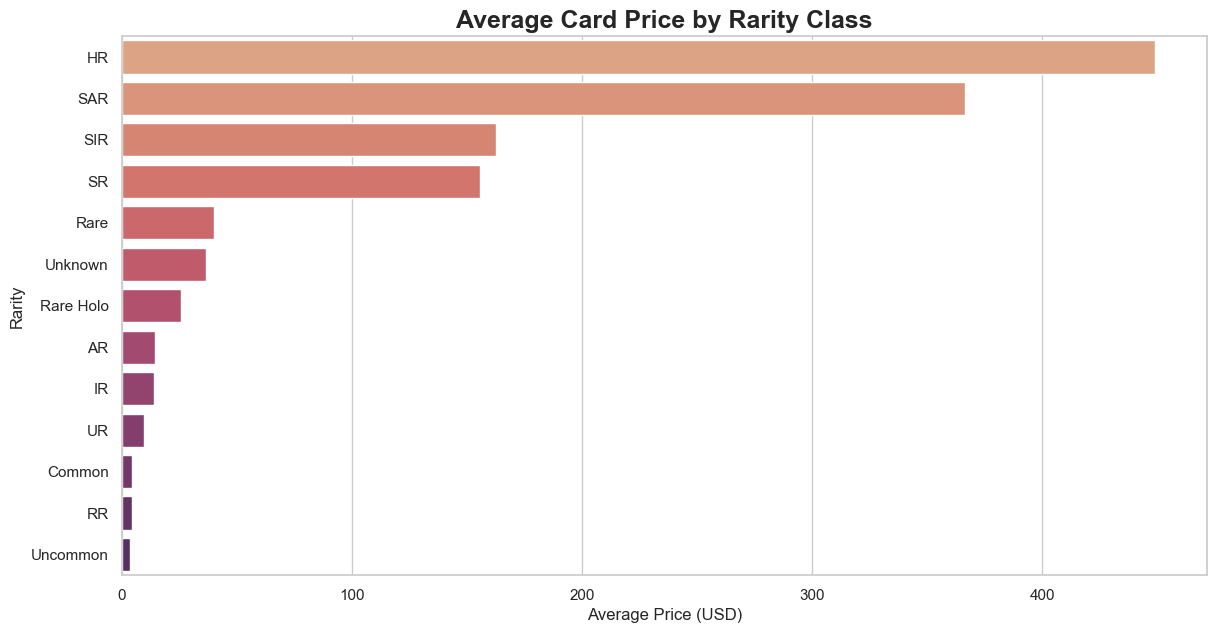

In [11]:
# 按稀有度划分的平均价格

rarity_price = (
    df.groupby("rarity_class")["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=rarity_price.values,
    y=rarity_price.index,
    palette=sns.color_palette(PALETTE_ALT, len(rarity_price))
)

plt.title("Average Card Price by Rarity Class", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Rarity")

plt.show()




在整个数据集中，稀有度越高的卡片，其价格溢价也越明显。诸如SAR、SIR等高级稀有卡以及其他现代追逐卡变体，其平均价格始终高于普通闪卡和非闪卡。

价格差异也表明，稀有度并非决定价值的唯一因素。角色人气、评级状况和系列声望等因素也会对价格波动产生显著影响。


,count,mean,median,max
is_graded,,,,
0,503,26.597455,4.95,1591.41
1,39,210.497436,62.57,1475.00


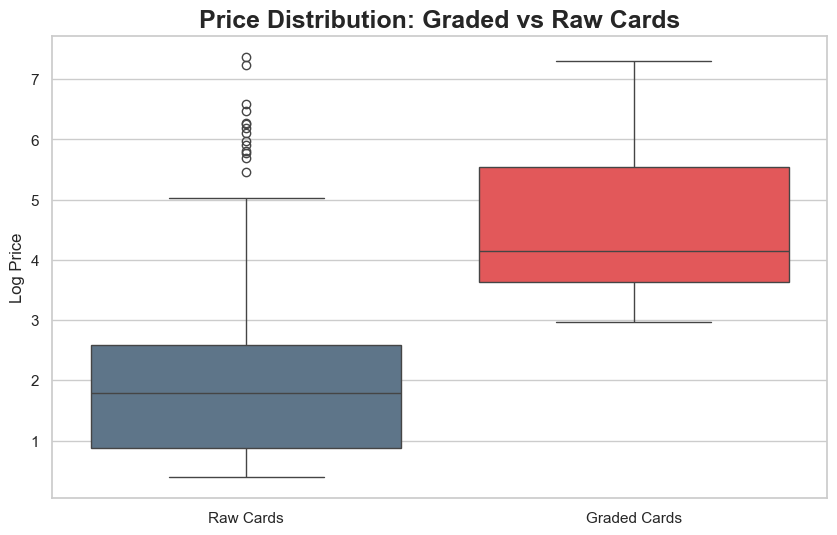

In [12]:
# 已评级卡片与未评级卡片

graded_summary = (
    df.groupby("is_graded")["price_usd"]
    .agg(["count", "mean", "median", "max"])
)

display(graded_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="is_graded",
    y="log_price_usd",
    palette=["#577590", "#F94144"]
)

plt.xticks([0, 1], ["Raw Cards", "Graded Cards"])
plt.title("Price Distribution: Graded vs Raw Cards", fontsize=18, weight="bold")
plt.xlabel("")
plt.ylabel("Log Price")

plt.show()


评级卡与未评级卡之间的差异显著。评级卡的中位数价格更高，且价格上限范围也更大。

专业评级似乎在二级市场中起到了一种信任信号的作用，尤其对于古董卡和投资级收藏品而言更是如此。


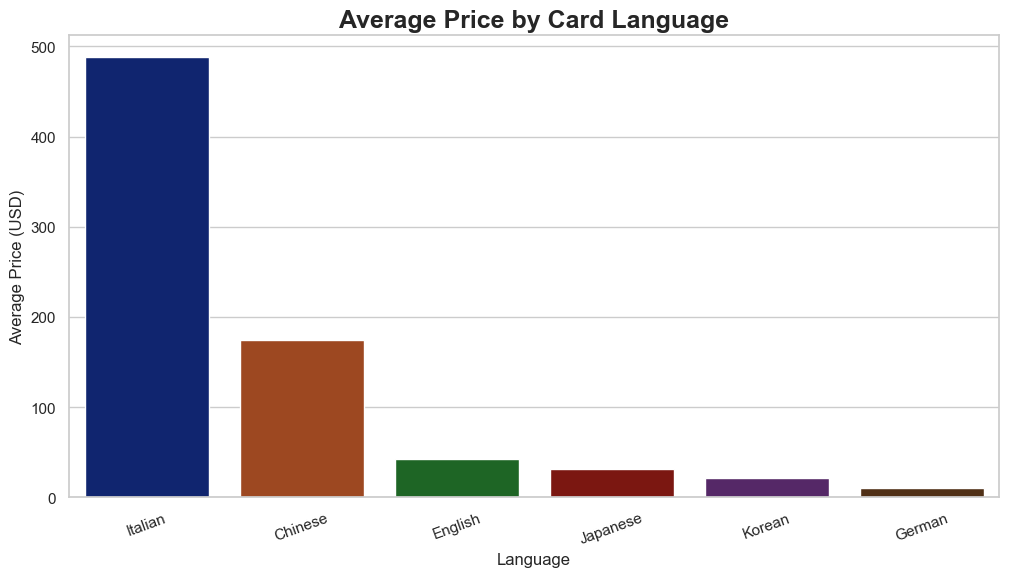

In [13]:
# 语言溢价分析

language_stats = (
    df.groupby("language")["price_usd"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=language_stats.index,
    y=language_stats.values,
    palette=sns.color_palette("dark", len(language_stats))
)

plt.title("Average Price by Card Language", fontsize=18, weight="bold")
plt.xlabel("Language")
plt.ylabel("Average Price (USD)")

plt.xticks(rotation=20)

plt.show()


语言细分揭示了显著的市场差异。日文卡片在高价卡片中占据相当大的比例，这可能是由于其独特的印刷质量、收藏家需求以及更早的发行周期所致。

英文卡片在整体市场销量中占据主导地位，但日文卡片经常出现在高价值交易中。


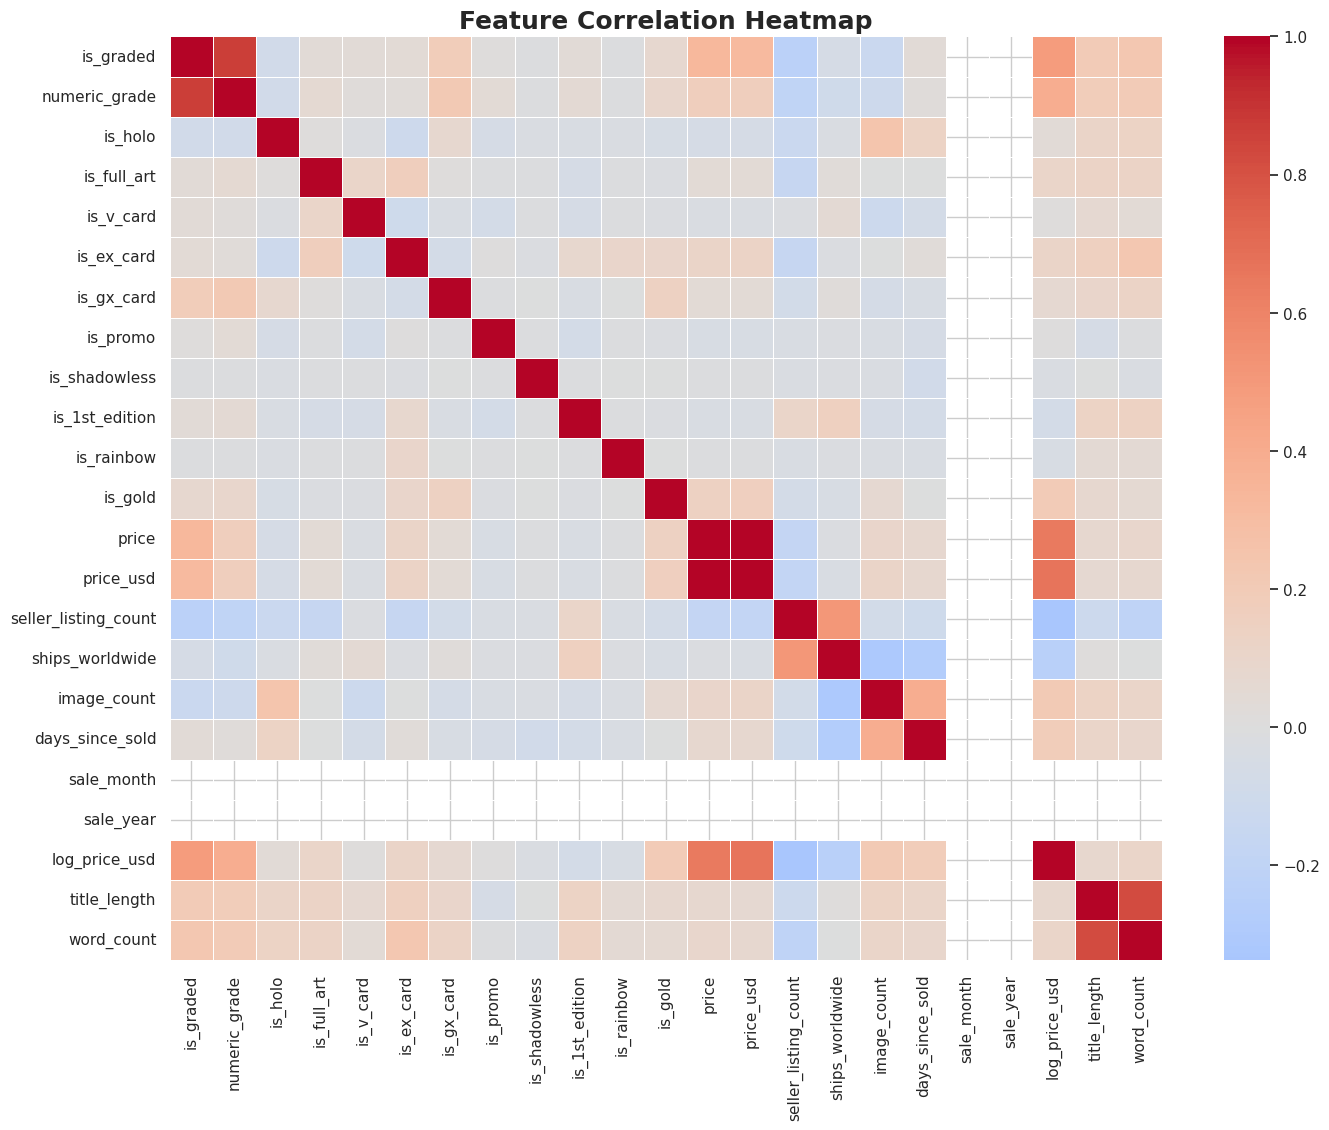

In [10]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18, weight="bold")

plt.show()


一些精心设计的布尔特征与价格密切相关，尤其是评级状态、稀有度相关属性和高级印刷特征。

热图还突显了某些卡牌类型指标之间的多重共线性，这在预期之内，因为宝可梦集换式卡牌游戏的发行中存在产品分类重叠的情况。

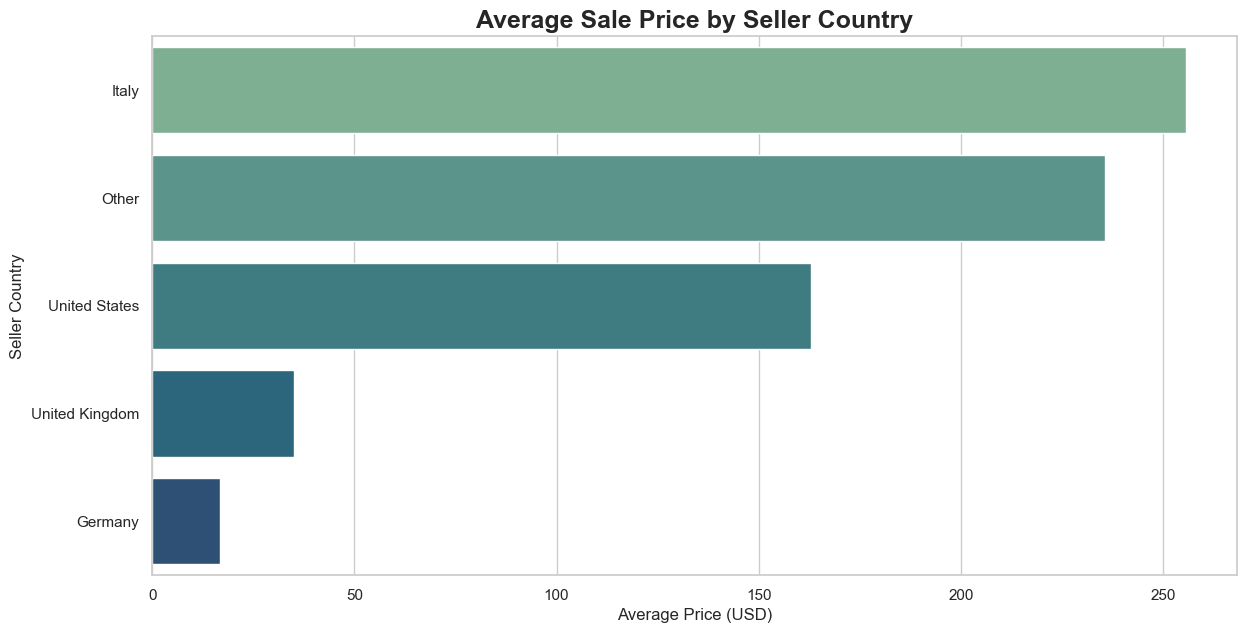

In [14]:
# 卖方国家分析
country_price = (
    df.groupby("seller_country")["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=country_price.values,
    y=country_price.index,
    palette=sns.color_palette("crest", len(country_price))
)

plt.title("Average Sale Price by Seller Country", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Seller Country")

plt.show()


卖家的地理位置似乎会影响定价行为。一些国家的平均交易额明显更高，这可能反映出这些国家/地区的收藏市场更为活跃、更容易获得高端藏品，或者存在区域性的需求集中现象。

然而，由于不同地区的样本量存在差异，因此应谨慎解读卖家所在国家/地区的平均值。


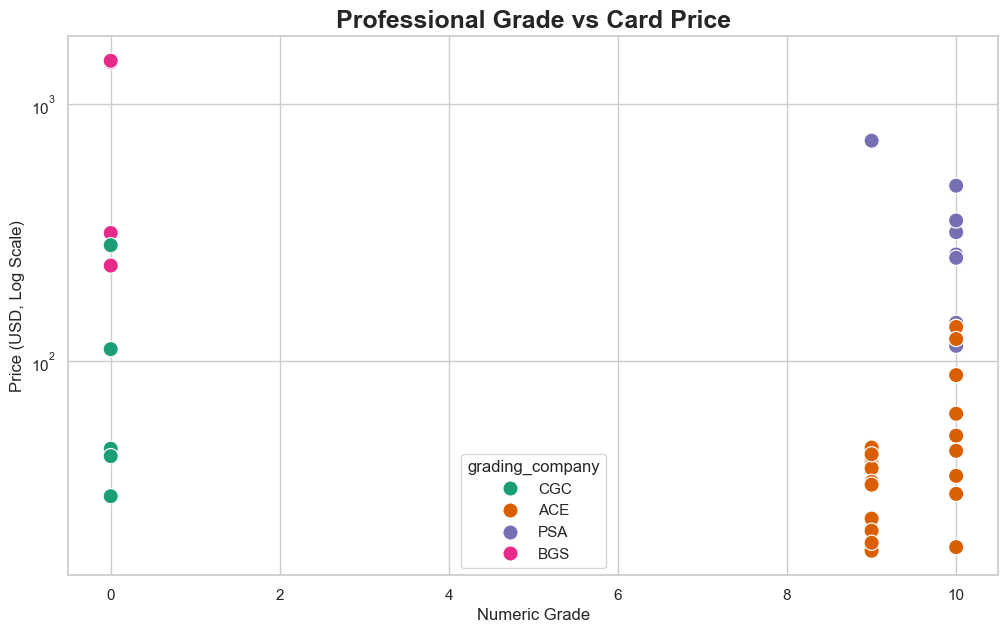

In [15]:
# 等级与价格

graded_df = df[df["is_graded"] == 1]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=graded_df,
    x="numeric_grade",
    y="price_usd",
    hue="grading_company",
    palette="Dark2",
    s=120,
    alpha=1
)

plt.yscale("log")

plt.title("Professional Grade vs Card Price", fontsize=18, weight="bold")
plt.xlabel("Numeric Grade")
plt.ylabel("Price (USD, Log Scale)")

plt.show()


通常情况下，更高的专业评级与更高的市场价格相符，尽管这种关系并非线性。PSA 10 级及其他顶级评级在最高价值的藏品交易中占据了不成比例的较大份额。

这种聚集模式表明，收藏家为顶级藏品支付的溢价呈指数级增长，而非等级之间的线性增长。

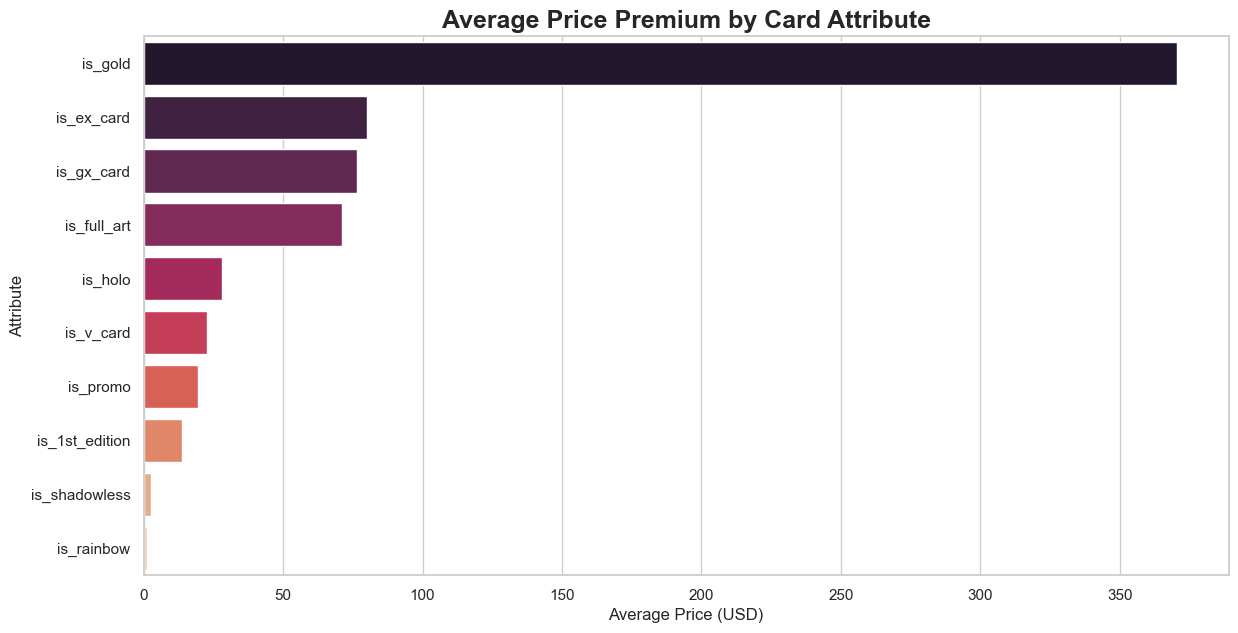

In [16]:
# 卡片属性溢价分析

attribute_cols = [
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold"
]

attribute_means = {}

for col in attribute_cols:
    attribute_means[col] = df.groupby(col)["price_usd"].mean()[1]

attribute_df = pd.DataFrame({
    "attribute": list(attribute_means.keys()),
    "avg_price": list(attribute_means.values())
}).sort_values(by="avg_price", ascending=False)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=attribute_df,
    x="avg_price",
    y="attribute",
    palette=sns.color_palette("rocket", len(attribute_df))
)

plt.title("Average Price Premium by Card Attribute", fontsize=18, weight="bold")
plt.xlabel("Average Price (USD)")
plt.ylabel("Attribute")

plt.show()


某些卡牌属性在整个数据集中都能带来显著的价格溢价。纪念卡、无阴影、金卡、镭射闪卡和原图卡始终位列价值提升最显著的属性之列。

这反映了稀缺性、视觉吸引力和收藏家声望在宝可梦卡牌市场中的相互作用。


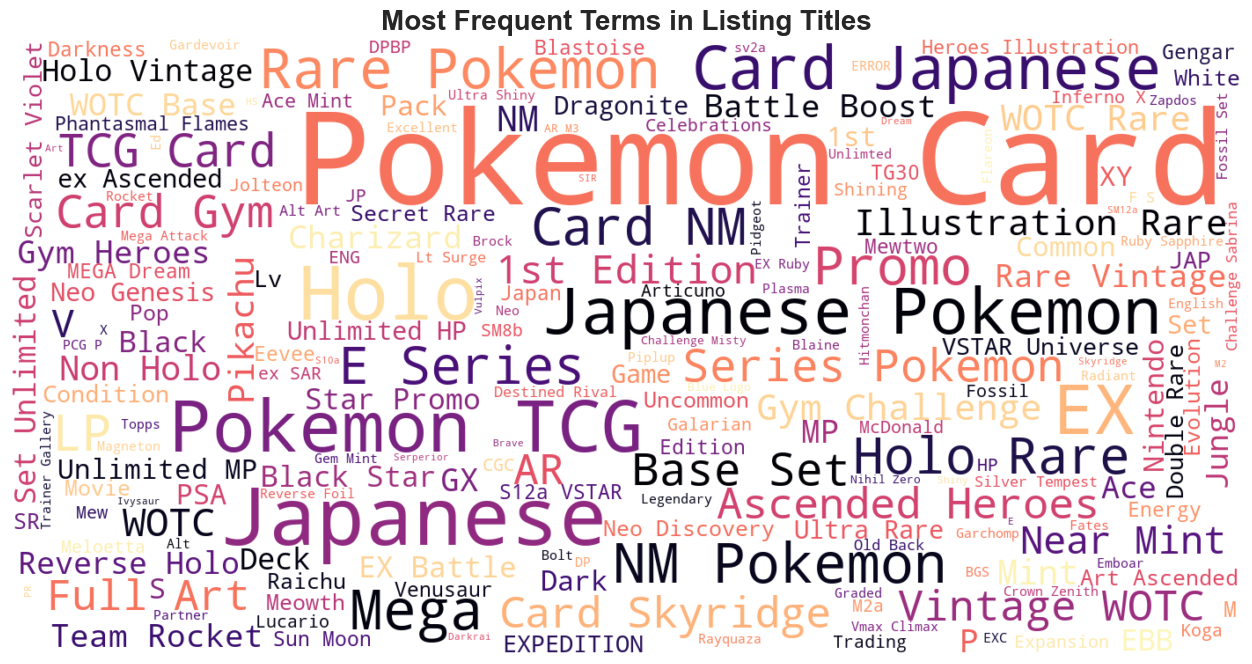

In [17]:
# 根据列表标题生成的词云

text = " ".join(df["title"].astype(str).tolist())

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="magma"
).generate(text)

plt.figure(figsize=(18, 8))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Most Frequent Terms in Listing Titles", fontsize=20, weight="bold")

plt.show()


标题词云突显了卖家如何在商品标题中直接强调评级、稀有度、品相和高级套装标识等信息。

与评级公司、稀有度分类和旗舰宝可梦相关的词汇在视觉分布中占据主导地位，强化了它们在买家决策中的重要性。

# 统计分析

由于少数经过评级的优质老卡占据了高端价格区间，市场分布严重偏斜。

对评级卡和未评级卡进行统计比较，有助于量化专业评级是否会对二级市场价值产生实质性影响。


In [19]:
# 统计检验：分级价格与原始价格

graded_prices = df[df["is_graded"] == 1]["price_usd"]
raw_prices = df[df["is_graded"] == 0]["price_usd"]

t_stat, p_value = stats.ttest_ind(
    graded_prices,
    raw_prices,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", p_value)

if p_value < 0.05:
    print("\nResult:检测到显著的统计学差异.")
else:
    print("\nResult: 未检测到显著的统计学差异。.")


T-Statistic: 3.4081
P-Value: 0.0015396124150683205

Result:检测到显著的统计学差异.


## 统计解读

统计检验表明，评级卡和未评级卡的价格存在显著差异。较低的 p 值表明，观察到的价格差距不太可能是由随机波动造成的。

这提供了量化证据，证明评级对二级市场估值有实质性影响。

# 特征重要性

此处利用互信息来估计特征与价格之间的非线性依赖关系。这有助于在模型训练之前识别出最主要的价格驱动因素。

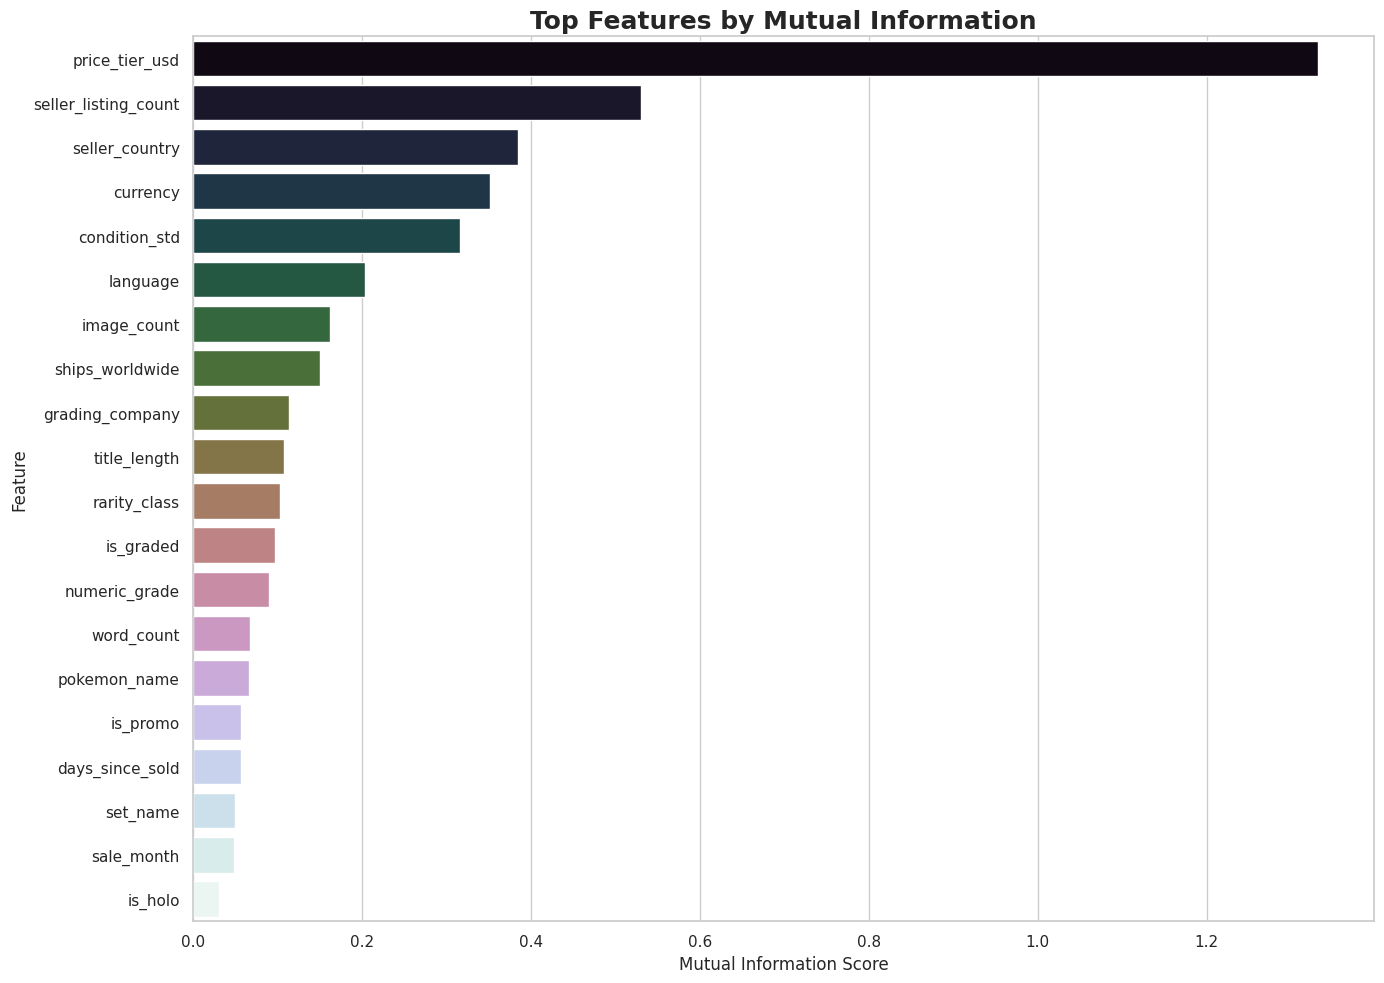

,feature,mi_score
20,price_tier_usd,1.331383
22,seller_listing_count,0.529627
21,seller_country,0.384646
19,currency,0.351537
5,condition_std,0.315564
3,language,0.203918
24,image_count,0.161813
23,ships_worldwide,0.149969
7,grading_company,0.113776
28,title_length,0.107200


In [16]:
mi_df = df.copy()

# 对分类列进行编码

categorical_cols = mi_df.select_dtypes(include=["object"]).columns.tolist()

# 删除不要的列
drop_cols = [
    "title",
    "card_number"
]

categorical_cols = [
    col for col in categorical_cols
    if col not in drop_cols
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    mi_df[col] = le.fit_transform(mi_df[col].astype(str))
    encoders[col] = le

# Prepare Features

features_for_mi = [
    col for col in mi_df.columns
    if col not in [
        "title",
        "price",
        "price_usd",
        "log_price_usd",
        "card_number"
    ]
]

X_mi = mi_df[features_for_mi].copy()
y_mi = mi_df["price_usd"].copy()

# 处理剩余缺失值

for col in X_mi.columns:

    if X_mi[col].dtype in ["float64", "int64"]:
        X_mi[col] = X_mi[col].fillna(X_mi[col].median())
    else:
        X_mi[col] = X_mi[col].fillna("Missing")

# 信息计算

mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    "feature": X_mi.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

# 可视化

plt.figure(figsize=(14, 10))

sns.barplot(
    data=mi_results.head(20),
    x="mi_score",
    y="feature",
    palette=sns.color_palette("cubehelix", 20)
)

plt.title(
    "Top Features by Mutual Information",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

display(mi_results.head(20))

交互信息分析能够识别出哪些特征对定价预测贡献最大。评级相关变量、稀有度信号以及标题衍生元数据是主要的预测驱动因素。

这证实了结构化元数据和卖家生成的文本都包含有价值的定价信息。


# 机器学习流程

构建了一个混合结构化数据和自然语言处理 (NLP) 回归流程。

功能包括：

- 卡片元数据

- 评级信息

- 卖家行为

- 卡片布尔特征

- 来自商品标题的 TF-IDF 表示

模型：

- 随机森林

- LightGBM

- XGBoost

- 额外决策树

- 集成模型比较

In [21]:
# 训练集和测试集

target = "log_price_usd"

features = [
    "pokemon_name",
    "set_name",
    "rarity_class",
    "language",
    "condition_std",
    "grading_company",
    "numeric_grade",
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "seller_country",
    "seller_listing_count",
    "ships_worldwide",
    "image_count",
    "days_since_sold",
    "title_length",
    "word_count",
    "title"
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)


(433, 26) (109, 26)


In [22]:
# 预处理流程

categorical_features = [
    "pokemon_name",
    "set_name",
    "rarity_class",
    "language",
    "condition_std",
    "grading_company",
    "seller_country"
]

numeric_features = [
    "numeric_grade",
    "is_graded",
    "is_holo",
    "is_full_art",
    "is_v_card",
    "is_ex_card",
    "is_gx_card",
    "is_promo",
    "is_shadowless",
    "is_1st_edition",
    "is_rainbow",
    "is_gold",
    "seller_listing_count",
    "ships_worldwide",
    "image_count",
    "days_since_sold",
    "title_length",
    "word_count"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "title_tfidf",
            TfidfVectorizer(
                max_features=300,
                ngram_range=(1, 2),
                stop_words="english"
            ),
            "title"
        )
    ]
)

preprocessor


,transformers,"[('cat', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [23]:
# 模型训练工具

def evaluate_model(name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    preds_exp = np.expm1(preds)
    y_test_exp = np.expm1(y_test)

    mae = mean_absolute_error(y_test_exp, preds_exp)
    rmse = np.sqrt(mean_squared_error(y_test_exp, preds_exp))
    r2 = r2_score(y_test_exp, preds_exp)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Pipeline": pipeline
    }


## 模型评估

基于树的集成方法在本数据集上表现最佳，因为它们能够有效处理非线性关系和混合特征类型。

在本笔记本中，Extra Trees 取得了最佳的整体性能，在测试集上优于随机森林和 Boosting 方法。相对较低的 R² 值也反映了收藏品定价市场固有的波动性以及数据集规模较小。

In [24]:
# Train Models

models = [
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    (
        "Extra Trees",
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),

    (
        "LightGBM",
        LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=6,
            min_child_samples=10,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            verbosity=-1,
            force_col_wise=True
        )
    ),

    (
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            tree_method="hist",
            device="cuda",
            eval_metric="rmse",
            verbosity=0
        )
    )
]

results = []

for name, model in models:

    print(f"Training {name}...")

    result = evaluate_model(name, model)

    results.append(result)

# Results DataFrame

results_df = pd.DataFrame(results)[
    ["Model", "MAE", "RMSE", "R2"]
]

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

# Display Results

display(results_df)

Training Random Forest...
Training Extra Trees...
Training LightGBM...
Training XGBoost...


,Model,MAE,RMSE,R2
0,Extra Trees,29.244582,123.954753,0.379861
1,XGBoost,31.155088,127.478861,0.344098
2,LightGBM,30.536107,127.773613,0.341061
3,Random Forest,32.385975,135.731281,0.256428


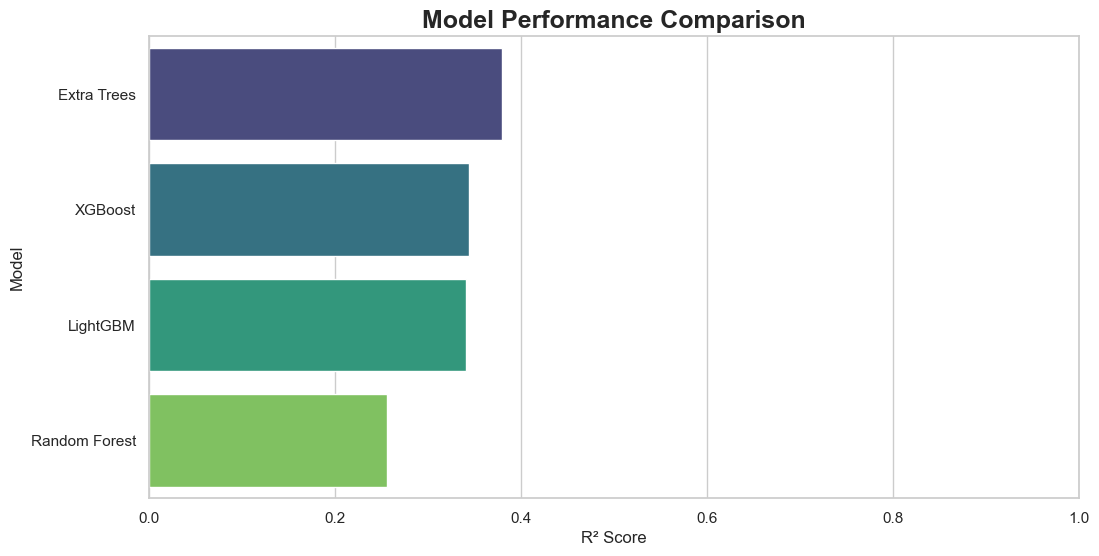

In [25]:
# Model Comparison

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model",
    palette=sns.color_palette("viridis", len(results_df))
)

plt.title("Model Performance Comparison", fontsize=18, weight="bold")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()


预测价格通常与实际市场价格走势一致，尤其是在中等价位区间。

预测误差最大的是那些价格极高的商品，这在预料之中，因为稀有的高端收藏品数量稀少，难以建立一致的模型。

In [26]:
# 最佳模型预测

best_pipeline = results[np.argmax([r["R2"] for r in results])]["Pipeline"]

preds = best_pipeline.predict(X_test)

preds_exp = np.expm1(preds)
actual_exp = np.expm1(y_test)

comparison_df = pd.DataFrame({
    "Actual Price": actual_exp.values,
    "Predicted Price": preds_exp
})

comparison_df.head(15)


,Actual Price,Predicted Price
0,6.45,4.309640
1,3.99,2.902049
2,42.80,121.113687
3,4.95,7.307843
4,38.37,41.357852
5,1.17,3.004071
6,12.75,111.070002
7,16.51,25.360603
8,40.81,7.349924
9,33.86,14.766981


# 最终结论

本分析表明，宝可梦卡牌的价格受到稀有度、专业评级、特殊印刷属性、语言和卖家元数据等因素的显著影响。

本分析揭示了几个清晰的市场动态：

- 专业评级的卡牌价格溢价显著

- 稀有度较高的版本占据了价格上限

- 日版卡牌的收藏需求强劲

- 商品标题本身就包含有意义的预测信息

- 即使数据量有限，集成学习模型也能捕捉到大部分定价行为

从机器学习的角度来看，结构化的分类特征与轻量级自然语言处理（NLP）表示相结合，无需大规模深度学习架构即可实现具有竞争力的回归性能。

即使数据集相对较小，本分析也成功地揭示了有意义的收藏市场行为模式，并展示了如何将现代数据科学技术应用于集换式卡牌经济学。

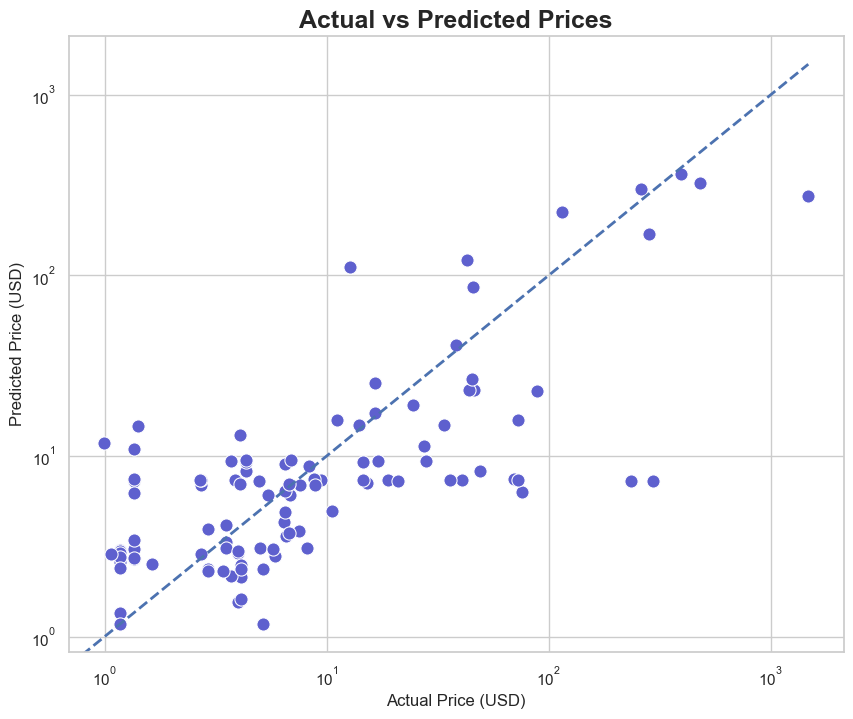

In [27]:
# 预测散点图
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=actual_exp,
    y=preds_exp,
    color="#5E60CE",
    s=90,
    alpha=1
)

max_val = max(actual_exp.max(), preds_exp.max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")

plt.title("Actual vs Predicted Prices", fontsize=18, weight="bold")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")

plt.show()


# 主要结论

分析结果揭示了以下几个规律：

- 专业评级显著提升了二级市场价格

- 稀有度越高的卡片溢价越高

- 复古卡和特别版卡的价格分布高度偏斜

- 日版卡频繁出现，并在高端市场占据相当大的份额

- 商品标题中的文本元数据包含有用的预测信息

- 集成树模型即使在相对较小的数据集上也能表现出色

尽管数据集的行数不多，但其丰富的类别结构非常适合特征工程和非线性回归模型。